# Demonstration of PaddockTS downstream analysis
This notebook contains code to generate Figures in the PaddockTS manuscript

## Location
Milgadara, NSW. A mixed cropping/grazing enterprise where the owners are experimenting with regenerative agriculture practices. 

## PaddockTS run
PaddockTS was run in the auto-segmentation mode and user-provided paddocks mode (see code snippet below). The run can be replicated with the code below. Downloading S2 took about 2 hours for 2018-2025. You could run it for only 2 years to replicate the notebook, and this will also yield different segmentation results. 


## Setup

In [1]:
from pathlib import Path
import os

# Move from downstream/ to repository root
repo_root = Path.cwd().parent
os.chdir(repo_root)

print("Working directory:", Path.cwd())

Working directory: /Users/johnburley/scratch/paddocktimeseries


In [2]:
# First, recreate the query as in the demonstration run (block above). 

from datetime import date
from troi import Troi
from PaddockTS.get_outputs import get_outputs

paddocks_fp = "artifacts/Milgadara_paddock-polygons_2024-12-17_12-45-58.json"

q = Troi.build_from_paddocks(
    paddocks_filepath=paddocks_fp,
    start=date(2018, 1, 1),
    end=date(2025, 12, 31),
    stub="Milgadara_2018-25",
    label_col="title",
)

### Establish variables

In [3]:
from pathlib import Path
import json

from troi import config

# PaddockTS run identifier
stub = "Milgadara_2018-25"

# User-provided paddocks
user_paddocks_path = Path(
    "artifacts/Milgadara_paddock-polygons_2024-12-17_12-45-58.json"
)

# Existing PaddockTS directories
paddockts_tmp = Path(config.tmp_dir) / stub
paddockts_out = Path(config.out_dir) / stub

# Outputs created by this notebook
#outpath = paddockts_out / "Case_study_figures"
outpath = Path("manuscript/figures")
outpath.mkdir(parents=True, exist_ok=True)


def get_query_from_stub(stub, registry_path=None):
    """Look up an existing PaddockTS query record by stub."""
    if registry_path is None:
        registry_path = Path(config.out_dir) / "queries.json"

    with open(registry_path) as f:
        registry = json.load(f)

    for bbox_hash, entry in registry.items():
        for query_record in entry["queries"]:
            if query_record["stub"] == stub:
                return {
                    "bbox_hash": bbox_hash,
                    "bbox": entry["bbox"],
                    **query_record,
                }

    raise ValueError(f"No query found with stub: {stub}")


query_info = get_query_from_stub(stub)
query_info

{'bbox_hash': '4061fa8fd4c1436da3c5aecefe76cfc2c6bc55c845f33ba0747fcbd174687a39',
 'bbox': [148.463559, -34.427456, 148.508107, -34.36811],
 'stub': 'Milgadara_2018-25',
 'start': '2018-01-01',
 'end': '2025-12-31',
 'time_hash': '6ed291277644c407946e05f65367e9d3fc2276d5f4ac6827646bd840a84cd5cf',
 'created_at': '2026-08-11T15:21:42.644487Z',
 'last_run_at': '2026-09-04T15:58:16.549801Z'}

In [4]:
# Cached per-troi artefacts, via the pipeline's own path derivation
from PaddockTS.paths import Paths

paths = Paths(q)

# Auto-generated SAMGeo paddock boundaries
auto_paddocks_path = Path(paths.sam_paddocks)

# Raw SAMGeo output before PaddockTS filtering
auto_paddocks_raw_path = Path(paths.sam_raw)


In [5]:
assert user_paddocks_path.exists(), user_paddocks_path
assert paddockts_tmp.exists(), paddockts_tmp
assert paddockts_out.exists(), paddockts_out
assert auto_paddocks_path.exists(), auto_paddocks_path


### Figure 2: paddock boundaries

In [6]:
## Clean up the two polygon sets

import geopandas as gpd

min_area_ha = 5

auto_paddocks = gpd.read_file(auto_paddocks_path)
user_features = gpd.read_file(user_paddocks_path)

# Keep only polygon features classified as user paddocks
user_paddocks = user_features[
    (user_features["type"] == "paddock")
    & user_features.geometry.geom_type.isin(["Polygon", "MultiPolygon"])
].copy()

# Counts before area filtering
n_user_before = len(user_paddocks)
n_auto_before = len(auto_paddocks)

# Remove small paddocks
user_paddocks = user_paddocks[
    user_paddocks["area_hectares"] >= min_area_ha
].copy()

auto_paddocks = auto_paddocks[
    auto_paddocks["area_ha"] >= min_area_ha
].copy()

# Reset dataframe indices only — paddock IDs remain unchanged
user_paddocks = user_paddocks.reset_index(drop=True)
auto_paddocks = auto_paddocks.reset_index(drop=True)

# Report
print(f"Minimum paddock area: {min_area_ha} ha")
print(
    f"User paddocks: {len(user_paddocks)} retained "
    f"({n_user_before - len(user_paddocks)} dropped)"
)
print(
    f"Auto paddocks: {len(auto_paddocks)} retained "
    f"({n_auto_before - len(auto_paddocks)} dropped)"
)

Minimum paddock area: 5 ha
User paddocks: 34 retained (8 dropped)
Auto paddocks: 64 retained (0 dropped)


In [7]:
auto_paddocks.head()


,value,area_ha,compactness,paddock,geometry
0,255.0,92.569188,0.248441,1,"POLYGON ((14327930 -4132110, 14327930 -4132120..."
1,255.0,59.229129,0.319230,2,"POLYGON ((14324720 -4136760, 14324720 -4136780..."
2,255.0,44.825074,0.461699,3,"POLYGON ((14328110 -4132640, 14328110 -4132650..."
3,255.0,42.765913,0.499749,4,"POLYGON ((14328940 -4133320, 14328940 -4133330..."
4,255.0,42.165768,0.454881,5,"POLYGON ((14327420 -4134680, 14327420 -4134690..."


In [8]:
## Read the Fourier Transform 3-band image that was input to sam geo

from pathlib import Path
import rasterio
import numpy as np
from rasterio.plot import plotting_extent

fourier_path = Path(paths.preseg)

with rasterio.open(fourier_path) as src:
    print("Bands:", src.count)
    print("Dtype:", src.dtypes)
    print("CRS:", src.crs)
    print("Bounds:", src.bounds)

    fourier = src.read([1, 2, 3])
    fourier_extent = plotting_extent(src)
    fourier_crs = src.crs

fourier_rgb = np.moveaxis(fourier, 0, -1)

print(fourier_rgb.shape)
print(fourier_rgb.min(), fourier_rgb.max())

Bands: 3
Dtype: ('uint8', 'uint8', 'uint8')
CRS: EPSG:6933
Bounds: BoundingBox(left=14324690.0, bottom=-4138380.0, right=14329000.0, top=-4132090.0)
(629, 431, 3)
0 255


inline


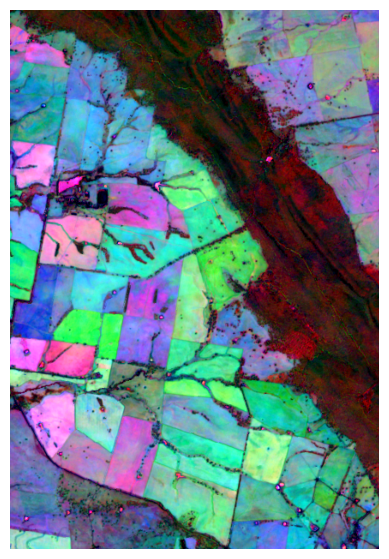

In [9]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
import matplotlib
print(matplotlib.get_backend())


def percentile_stretch(rgb, lower=2, upper=98):
    """Stretch each RGB band independently between percentile limits."""
    
    stretched = np.zeros_like(rgb, dtype=float)

    for band in range(3):
        x = rgb[..., band].astype(float)

        lo, hi = np.nanpercentile(x, [lower, upper])

        stretched[..., band] = np.clip(
            (x - lo) / (hi - lo),
            0,
            1,
        )

    return stretched


fourier_rgb_stretched = percentile_stretch(
    fourier_rgb,
    lower=2,
    upper=98,
)

fig, ax = plt.subplots(figsize=(7, 7))

ax.imshow(
    fourier_rgb_stretched,
    extent=fourier_extent,
    origin="upper",
)

ax.set_axis_off()
plt.show()

In [10]:
### Download a high-res aerial image (only if it does not already exist)

import contextily as cx  # may need to pip install contextily
from pathlib import Path

user_paddocks_web = user_paddocks.to_crs(epsg=3857)

NSW_IMAGERY = (
    "https://maps.six.nsw.gov.au/arcgis/rest/services/"
    "public/NSW_Imagery/MapServer/tile/{z}/{y}/{x}"
)

aerial_path = Path("artifacts/Milgadara_NSW_imagery_z15.tif")

if not aerial_path.exists():
    aerial_path.parent.mkdir(parents=True, exist_ok=True)

    west, south, east, north = user_paddocks_web.total_bounds

    cx.bounds2raster(
        west,
        south,
        east,
        north,
        aerial_path,
        zoom=15,
        source=NSW_IMAGERY,
    )

    print(f"Downloaded aerial imagery to {aerial_path}")
else:
    print(f"Using existing aerial imagery: {aerial_path}")

Using existing aerial imagery: artifacts/Milgadara_NSW_imagery_z15.tif


In [11]:
import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling

aerial_path = Path("artifacts/Milgadara_NSW_imagery_z15.tif")

# Reproject aerial imagery directly onto the Fourier raster grid
with rasterio.open(aerial_path) as aerial_src, \
     rasterio.open(fourier_path) as fourier_src:

    aerial_fourier = np.zeros(
        (3, fourier_src.height, fourier_src.width),
        dtype=np.uint8
    )

    for band in range(3):
        reproject(
            source=rasterio.band(aerial_src, band + 1),
            destination=aerial_fourier[band],
            src_transform=aerial_src.transform,
            src_crs=aerial_src.crs,
            dst_transform=fourier_src.transform,
            dst_crs=fourier_src.crs,
            resampling=Resampling.bilinear,
        )

aerial_fourier_rgb = np.moveaxis(aerial_fourier, 0, -1)

In [12]:
print(fourier_crs)

EPSG:6933


findfont: Failed to find font weight semibold, now using 700.
findfont: Failed to find font weight semibold, now using 700.


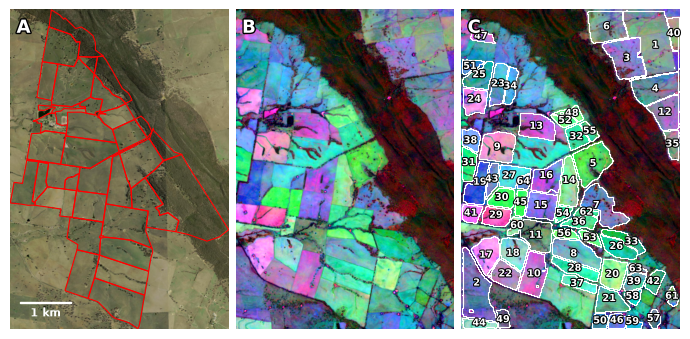

In [13]:
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import matplotlib.font_manager as fm
import matplotlib.patheffects as pe
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# Settings
# ---------------------------------------------------------------------

show_auto_labels = True
auto_label_fontsize = 7

# ---------------------------------------------------------------------
# Reproject paddocks to match Fourier CRS
# ---------------------------------------------------------------------

user_paddocks_fourier = user_paddocks.to_crs(fourier_crs)
auto_paddocks_fourier = auto_paddocks.to_crs(fourier_crs)

# ---------------------------------------------------------------------
# Build figure
# ---------------------------------------------------------------------

fig, axes = plt.subplots(
    ncols=3,
    figsize=((6.7, 3.9)),
)

# ============================================================
# A. Aerial imagery + user paddocks
# ============================================================

ax = axes[0]

ax.imshow(
    aerial_fourier_rgb,
    extent=fourier_extent,
    origin="upper",
)

user_paddocks_fourier.boundary.plot(
    ax=ax,
    color="red",
    linewidth=0.8,
    zorder=3,
)

# Scale bar
scalebar = AnchoredSizeBar(
    ax.transData,
    1000,                   # 1000 map units = 1 km
    "1 km",
    loc="lower left",
    pad=0.4,
    borderpad=0.5,
    sep=3,
    frameon=False,
    size_vertical=20,
    color="white",
    fontproperties=fm.FontProperties(size=8, weight="semibold"),
)

ax.add_artist(scalebar)
ax.set_axis_off()


# ============================================================
# B. Fourier false-colour image
# ============================================================

ax = axes[1]

ax.imshow(
    fourier_rgb_stretched,
    extent=fourier_extent,
    origin="upper",
)

ax.set_axis_off()


# ============================================================
# C. Fourier image + auto paddocks
# ============================================================

ax = axes[2]

ax.imshow(
    fourier_rgb_stretched,
    extent=fourier_extent,
    origin="upper",
)

auto_paddocks_fourier.boundary.plot(
    ax=ax,
    color="white",
    linewidth=0.8,
    zorder=3,
)

# Optional integer paddock labels
if show_auto_labels:
    for _, row in auto_paddocks_fourier.iterrows():
        point = row.geometry.representative_point()

        ax.text(
            point.x,
            point.y,
            str(row["paddock"]),
            ha="center",
            va="center",
            fontsize=auto_label_fontsize,
            fontweight="semibold",
            color="white",
            zorder=5,
            path_effects=[
                pe.withStroke(linewidth=1.5, foreground="black")
            ],
        )

ax.set_axis_off()


# ============================================================
# Panel labels
# ============================================================

for ax, label in zip(axes, ["A", "B", "C"]):
    ax.text(
        0.03,
        0.97,
        label,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=13,
        fontweight="bold",
        color="white",
        path_effects=[
            pe.withStroke(linewidth=2, foreground="black")
        ],
        zorder=10,
    )

# ---------------------------------------------------------------------
# Final layout
# ---------------------------------------------------------------------

plt.subplots_adjust(
    wspace=0.03,
    left=0,
    right=1,
    top=1,
    bottom=0,
)

plt.show()

In [14]:
fig.savefig(
    outpath / "Figure2_Milgadara_segmentation.svg",
    bbox_inches="tight",
    pad_inches=0.02,
)

### Read in the resampled, interpolated, smoothed paddock time series. 
For Figure 3 (paddock-level vegetation dynamics)

In [15]:
import xarray as xr

paddockts_smoothed_auto = xr.open_zarr(
    paddockts_tmp / "sam_paddocks_timeseries_smoothed.zarr"
)

# Match polygon ID datatype
paddockts_smoothed_auto = paddockts_smoothed_auto.assign_coords(
    paddock=paddockts_smoothed_auto["paddock"].astype(int)
)

print(paddockts_smoothed_auto)

<xarray.Dataset> Size: 3MB
Dimensions:           (paddock: 64, time: 292)
Coordinates:
  * paddock           (paddock) int64 512B 1 2 3 4 5 6 7 ... 59 60 61 62 63 64
  * time              (time) datetime64[ns] 2kB 2018-01-03 ... 2025-12-22
    cloud_fraction    (time) float64 2kB dask.array<chunksize=(292,), meta=np.ndarray>
    snow_fraction     (time) float64 2kB dask.array<chunksize=(292,), meta=np.ndarray>
    valid_fraction    (time) float64 2kB dask.array<chunksize=(292,), meta=np.ndarray>
    spatial_ref       int32 4B ...
Data variables: (12/19)
    bg                (paddock, time) float64 150kB dask.array<chunksize=(64, 292), meta=np.ndarray>
    CAI               (paddock, time) float64 150kB dask.array<chunksize=(64, 292), meta=np.ndarray>
    CFI               (paddock, time) float64 150kB dask.array<chunksize=(64, 292), meta=np.ndarray>
    nbart_blue        (paddock, time) float64 150kB dask.array<chunksize=(64, 292), meta=np.ndarray>
    nbart_green       (paddock, time

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


def fractional_cover_rgb(ds):
    """Convert bg, pv and npv fractional cover to an RGB array."""

    rgb = np.stack([
        ds["bg"].values,   # red
        ds["pv"].values,   # green
        ds["npv"].values,  # blue
    ], axis=-1)

    # Fractional cover is stored as percentages
    if np.nanmax(rgb) > 1.5:
        rgb = rgb / 100

    return np.clip(rgb, 0, 1)

In [17]:
def plot_fractional_cover_heatmap(
    ds,
    paddocks=None,
    figsize=((6.7, 3.9)),
    show_paddock_labels=False,
):
    """Plot multi-year paddock fractional-cover trajectories as RGB."""

    # Select paddocks, preserving the supplied order
    if paddocks is not None:
        ds = ds.sel(paddock=paddocks)

    rgb = fractional_cover_rgb(ds)

    times = ds["time"].values
    paddock_ids = ds["paddock"].values

    # Convert dates to matplotlib coordinates
    x = mdates.date2num(times)

    fig, ax = plt.subplots(figsize=figsize)

    ax.imshow(
        rgb,
        aspect="auto",
        interpolation="nearest",
        extent=[
            x[0],
            x[-1],
            len(paddock_ids) - 0.5,
            -0.5,
        ],
    )

    # Date axis
    ax.xaxis_date()
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

    # Paddock axis
    if show_paddock_labels:
        ax.set_yticks(np.arange(len(paddock_ids)))
        ax.set_yticklabels(paddock_ids)
        ax.set_ylabel("Paddock")
    else:
        ax.set_yticks([])

    ax.set_xlabel("Year")

    plt.tight_layout()

    return fig, ax

In [18]:
import pandas as pd

def plot_fractional_cover_heatmap(
    ds,
    paddocks=None,
    figsize=(6.7, 3.9),
    show_paddock_labels=False,
):
    """Plot multi-year paddock fractional-cover trajectories as RGB."""

    # Select paddocks, preserving the supplied order
    if paddocks is not None:
        ds = ds.sel(paddock=paddocks)

    rgb = fractional_cover_rgb(ds)

    times = ds["time"].values
    paddock_ids = ds["paddock"].values

    # Convert dates to matplotlib coordinates
    x = mdates.date2num(times)

    fig, ax = plt.subplots(figsize=figsize)

    ax.imshow(
        rgb,
        aspect="auto",
        interpolation="nearest",
        extent=[
            x[0],
            x[-1],
            len(paddock_ids) - 0.5,
            -0.5,
        ],
    )

    # ------------------------------------------------------------
    # Date axis
    # ------------------------------------------------------------

    ax.xaxis_date()
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

    # Extend axis back to Jan 1 so the first year (2018) is shown
    first_year = pd.to_datetime(times[0]).replace(
        month=1,
        day=1,
        hour=0,
        minute=0,
        second=0,
        microsecond=0,
    )

    ax.set_xlim(
        mdates.date2num(first_year),
        x[-1],
    )

    # Put x-axis ticks and label above the plot
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position("top")

    ax.tick_params(
        axis="x",
        top=True,
        labeltop=True,
        bottom=False,
        labelbottom=False,
    )

    ax.tick_params(axis="y", labelsize=8)

    ax.set_xlabel("Date")

    # ------------------------------------------------------------
    # Paddock axis
    # ------------------------------------------------------------

    if show_paddock_labels:
        tick_idx = np.arange(0, len(paddock_ids), 2)
    
        ax.set_yticks(tick_idx)
        ax.set_yticklabels(paddock_ids[tick_idx])
        ax.set_ylabel("Paddock")
    else:
        ax.set_yticks([])

    plt.tight_layout()

    return fig, ax

[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31]


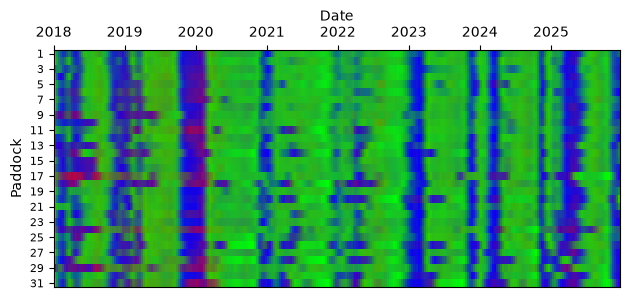

In [19]:

paddocks_to_plot = auto_paddocks["paddock"].iloc[:31].to_numpy()

print(paddocks_to_plot)

fig, ax = plot_fractional_cover_heatmap(
    paddockts_smoothed_auto,
    paddocks=paddocks_to_plot,
    figsize=((6.4, 3.1)),
    show_paddock_labels=True,
)

plt.show()

fig.savefig(
    outpath / "Figure3_paddocktimeseries_Milgadara_auto_largest31_vegfrac.svg",
    bbox_inches="tight",
    pad_inches=0.02,
)

In [20]:
### Color scale for the fractional cover figure:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.path import Path as MplPath

def make_fractional_cover_triangle_legend(
    figsize=(1.6, 1.5),
    labels=("PV", "BG", "NPV"),
):
    """
    Create a compact ternary-style RGB legend for fractional cover.

    RGB mapping:
        BG  -> red
        PV  -> green
        NPV -> blue
    """

    # Triangle vertices:
    # top = PV, bottom-left = BG, bottom-right = NPV
    v_pv = np.array([0.5, np.sqrt(3) / 2])
    v_bg = np.array([0.0, 0.0])
    v_npv = np.array([1.0, 0.0])

    # Dense grid in unit square, later mask to triangle
    n = 300
    x = np.linspace(0, 1, n)
    y = np.linspace(0, np.sqrt(3) / 2, n)
    xx, yy = np.meshgrid(x, y)

    pts = np.column_stack([xx.ravel(), yy.ravel()])

    # Triangle path for masking
    tri_path = MplPath([v_bg, v_npv, v_pv, v_bg])
    inside = tri_path.contains_points(pts)
    pts_in = pts[inside]

    # Barycentric coordinates
    # Solve p = w_bg*v_bg + w_npv*v_npv + w_pv*v_pv
    T = np.column_stack([v_bg - v_pv, v_npv - v_pv])
    b = (pts_in - v_pv).T
    sol = np.linalg.solve(T, b)
    w_bg = sol[0]
    w_npv = sol[1]
    w_pv = 1 - w_bg - w_npv

    # RGB mapping
    rgb = np.column_stack([
        w_bg,   # red
        w_pv,   # green
        w_npv,  # blue
    ])
    rgb = np.clip(rgb, 0, 1)

    fig, ax = plt.subplots(figsize=figsize)

    # Use tiny square markers to fill the triangle
    ax.scatter(
        pts_in[:, 0],
        pts_in[:, 1],
        c=rgb,
        s=3,
        marker="s",
        linewidths=0,
    )

    # Triangle outline
    tri_x = [v_bg[0], v_npv[0], v_pv[0], v_bg[0]]
    tri_y = [v_bg[1], v_npv[1], v_pv[1], v_bg[1]]
    ax.plot(tri_x, tri_y, color="black", linewidth=0.8)

    # Labels
    ax.text(
        v_pv[0],
        v_pv[1] + 0.06,
        labels[0],
        ha="center",
        va="bottom",
        fontsize=7,
        fontweight="bold",
    )
    ax.text(
        v_bg[0] - 0.05,
        v_bg[1] - 0.03,
        labels[1],
        ha="right",
        va="top",
        fontsize=7,
        fontweight="bold",
    )
    ax.text(
        v_npv[0] + 0.05,
        v_npv[1] - 0.03,
        labels[2],
        ha="left",
        va="top",
        fontsize=7,
        fontweight="bold",
    )

    ax.set_aspect("equal")
    ax.set_xlim(-0.12, 1.12)
    ax.set_ylim(-0.10, np.sqrt(3) / 2 + 0.12)
    ax.axis("off")

    return fig, ax


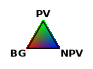

In [21]:
fig, ax = make_fractional_cover_triangle_legend(figsize=(0.5, 0.5))
plt.show()
fig.savefig(
    outpath / "fractional_cover_triangle_legend.pdf",
    bbox_inches="tight",
    pad_inches=0.01,
    transparent=False,
)
fig.savefig(
    outpath / "fractional_cover_triangle_legend.svg",
    bbox_inches="tight",
    pad_inches=0.01,
    transparent=True,
)

### Fig 3. the environmental data time series plot

In [22]:
### recreate this figure based on the old one. original: https://github.com/johnburley3000/PaddockTS/blob/main/Code/plotting_functions.py plot_env_ts()


In [23]:
### THIS IS TEMPORARY

# Future: do we need a function that recreates query from an an existing run?

from datetime import date
from troi import Troi
from PaddockTS.get_outputs import get_outputs

paddocks_fp = "artifacts/Milgadara_paddock-polygons_2024-12-17_12-45-58.json"

q = Troi.build_from_paddocks(
    paddocks_filepath=paddocks_fp,
    start=date(2018, 1, 1),
    end=date(2025, 12, 31),
    stub="Milgadara_2018-25",
    label_col="title",
)

q

Troi(bbox=[148.463559, -34.427456, 148.508107, -34.36811], start=datetime.date(2018, 1, 1), end=datetime.date(2025, 12, 31), stub='Milgadara_2018-25', config=Config(out_dir='/Users/johnburley/scratch/paddockts_out', tmp_dir='/Users/johnburley/scratch/paddockts_tmp', hash_file='/Users/johnburley/scratch/paddockts_out/queries.json', email='john.burley3000@gmail.com', tern_api_key='cmg3TlhpM0UyQ2ljSnQ5cy4gPVxkaSF+Z2g7SkFCc21oMGFILS1WR21oJC0lXj1sUmFrdXl0bVd5RlhzTDlkK0tzIGBoCyJgaTwnV3FdUzJG'), bbox_hash='4061fa8fd4c1436da3c5aecefe76cfc2c6bc55c845f33ba0747fcbd174687a39', time_hash='6ed291277644c407946e05f65367e9d3fc2276d5f4ac6827646bd840a84cd5cf', tmp_dir='/Users/johnburley/scratch/paddockts_tmp/Milgadara_2018-25', out_dir='/Users/johnburley/scratch/paddockts_out/Milgadara_2018-25', centre_lon=148.485833, centre_lat=-34.397783000000004)

In [24]:
## 8-day OzWALD variables (soil moisture etc.) from the machine-wide pyozwald store.
# Fetches only what the store is missing; repeat runs are instant.
# May take a little while as this part is not currently included in the default PaddockTS pipeline
# This step is a bit unpredictable.... sometimes doesnt work... server issue? 

from pyozwald.store import Store as OzStore

ozwald_8day = OzStore(config=q.config).get_df_troi(q, cadence='8day')
ozwald_8day = ozwald_8day.rename(columns={'date': 'time'})
ozwald_8day.head()


,time,Alb,BS,EVI,FMC,GPP,LAI,NDVI,NPV,OW,PV,Qtot,SN,Ssoil
0,2018-01-01,0.155,14.0,0.305,64.1,1.200595,1.04,0.465,47.5,0.0,39.0,0.042002,0.0,414.655823
1,2018-01-09,0.155,16.0,0.295,62.9,1.565256,1.01,0.455,43.5,0.0,40.5,0.038690,0.0,410.712463
2,2018-01-17,0.155,17.0,0.285,56.3,0.783024,0.98,0.450,43.0,0.0,39.5,0.022336,0.0,401.150940
3,2018-01-25,0.150,16.5,0.270,41.1,1.106462,0.91,0.435,48.0,0.0,35.5,0.042452,0.0,401.080963
4,2018-02-02,0.155,16.5,0.250,26.9,0.731312,0.82,0.415,55.0,0.0,28.5,0.020338,0.0,396.369904


In [25]:
import pandas as pd
from pysilo.store import Store as SiloStore

# Daily SILO climate from the machine-wide pysilo store
silo = SiloStore(config=q.config).get_df_troi(q).rename(columns={'date': 'time'})

print("SILO columns:")
print(silo.columns.tolist())
print()
print("OzWALD 8-day columns:")
print(ozwald_8day.columns.tolist())


SILO columns:
['time', 'daily_rain', 'et_morton_actual', 'et_morton_potential', 'et_morton_wet', 'et_short_crop', 'et_tall_crop', 'evap_comb', 'evap_morton_lake', 'evap_pan', 'evap_syn', 'max_temp', 'min_temp', 'mslp', 'radiation', 'rh_tmax', 'rh_tmin', 'vp', 'vp_deficit']

OzWALD 8-day columns:
['time', 'Alb', 'BS', 'EVI', 'FMC', 'GPP', 'LAI', 'NDVI', 'NPV', 'OW', 'PV', 'Qtot', 'SN', 'Ssoil']


In [26]:
import xarray as xr
import numpy as np

# Raw paddock time series before smoothing
paddockts_raw_auto = xr.open_zarr(
    paddockts_tmp / "sam_paddocks_timeseries.zarr"
).assign_coords(
    paddock=lambda ds: ds["paddock"].astype(int)
)

# Times when Sentinel-2 observations were actually present
obs_any = (
    paddockts_raw_auto["nbart_blue"]
    .notnull()
    .any(dim="paddock")
)

obs_dates = paddockts_raw_auto["time"].values[obs_any.values]

print(f"{len(obs_dates)} Sentinel-2 observation dates")
print(obs_dates[:10])

684 Sentinel-2 observation dates
['2018-01-03T00:00:00.000000000' '2018-01-05T00:00:00.000000000'
 '2018-01-10T00:00:00.000000000' '2018-01-15T00:00:00.000000000'
 '2018-01-18T00:00:00.000000000' '2018-01-28T00:00:00.000000000'
 '2018-01-30T00:00:00.000000000' '2018-02-04T00:00:00.000000000'
 '2018-02-12T00:00:00.000000000' '2018-02-14T00:00:00.000000000']


In [27]:
### Plot environmental time series

# first a function for nice arrows. 
from matplotlib.path import Path

# Custom downward arrow:
# rectangular shaft + flat-backed triangular head
arrow_vertices = [
    (-0.11,  0.65),   # top-left of shaft
    ( 0.11,  0.65),   # top-right
    ( 0.11, -0.10),   # bottom-right of shaft
    ( 0.42, -0.10),   # right shoulder / flat back of head
    ( 0.00, -0.75),   # sharp tip
    (-0.42, -0.10),   # left shoulder
    (-0.11, -0.10),   # bottom-left of shaft
    (-0.11,  0.65),   # close
]

arrow_codes = [
    Path.MOVETO,
    Path.LINETO,
    Path.LINETO,
    Path.LINETO,
    Path.LINETO,
    Path.LINETO,
    Path.LINETO,
    Path.CLOSEPOLY,
]

down_arrow_marker = Path(arrow_vertices, arrow_codes)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


def plot_env_ts(
    silo,
    ozwald_8day,
    obs_dates,
    figsize=(10, 5.5),
):
    """
    Plot rainfall, soil moisture, and temperature time series,
    with Sentinel-2 observation dates shown above rainfall.
    """

    plt.close("all")

    # Sort inputs
    silo = silo.copy().sort_values("time")
    ozwald_8day = ozwald_8day.copy().sort_values("time")

    # Convert Sentinel-2 timestamps to dates and remove duplicates
    obs_dates = (
        pd.Series(pd.to_datetime(obs_dates))
        .dt.normalize()
        .drop_duplicates()
        .sort_values()
        .to_numpy()
    )

    fig, axes = plt.subplots(
        nrows=3,
        ncols=1,
        figsize=figsize,
        sharex=True,
        constrained_layout=True,
    )

    # ------------------------------------------------------------
    # A. Rainfall + Sentinel-2 observations
    # ------------------------------------------------------------
    ax = axes[0]

    ax.bar(
        silo["time"],
        silo["daily_rain"],
        width=1.0,
        linewidth=0,
    )

    ax.set_ylabel("Rain\n(mm/day)")

    # Sentinel-2 observations as downward arrows.
    # x uses date coordinates; y uses axes coordinates,
    # so arrows remain aligned neatly along the top.
    ax.scatter(
        obs_dates,
        np.full(len(obs_dates), 0.94),
        marker=down_arrow_marker,
        s=32,
        facecolors="0.15",
        edgecolors="none",
        linewidths=0,
        alpha=0.5,
        transform=ax.get_xaxis_transform(),
        clip_on=True,
        label="Sentinel-2 observation",
    )

    ax.legend(
        loc="upper right",
        frameon=True,
        fontsize=8,
        bbox_to_anchor=(0.99, 0.92),
    )

    # ------------------------------------------------------------
    # B. Soil moisture
    # ------------------------------------------------------------
    ax = axes[1]

    ax.plot(
        ozwald_8day["time"],
        ozwald_8day["Ssoil"],
        linewidth=1.2,
    )

    ax.set_ylabel("Soil water\nstorage (mm)")
    ax.set_ylim(bottom=0)

    # ------------------------------------------------------------
    # C. Temperature
    # ------------------------------------------------------------
    ax = axes[2]

    ax.plot(
        silo["time"],
        silo["max_temp"],
        linewidth=0.6,
        label="Max temp",
        color = "red"
    )
    
    ax.plot(
        silo["time"],
        silo["min_temp"],
        linewidth=0.6,
        label="Min temp",
    )
    
    ax.set_ylabel("Temp\n(°C)")

    ax.legend(
        loc="upper right",
        frameon=True,
        fontsize=8,    
        bbox_to_anchor=(0.99, 0.99),
    )

    # ------------------------------------------------------------
    # Shared formatting
    # ------------------------------------------------------------

    axes[-1].xaxis.set_major_locator(mdates.YearLocator())
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    axes[-1].set_xlabel("Date")

    for ax in axes:
        ax.margins(x=0)

        # Explicitly enclose each panel
        for spine in ax.spines.values():
            spine.set_visible(True)

    return fig, axes

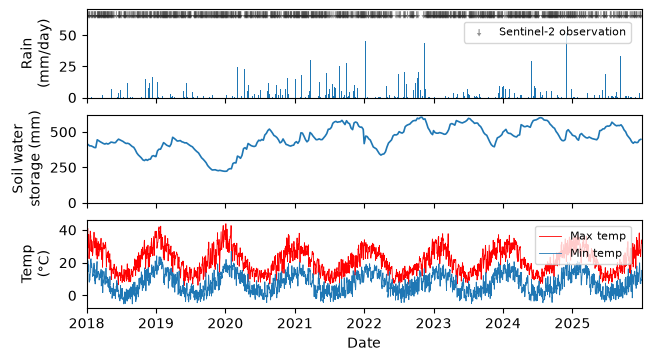

In [28]:
fig, axes = plot_env_ts(
    silo=silo,
    ozwald_8day=ozwald_8day,
    obs_dates=obs_dates,
    figsize=(6.4, 3.5),
)
# gets around a FigureCanvasAgg that was preventing plt.show()
%matplotlib inline 
plt.show()
plt.close()

fig.savefig(
    outpath / "environmental.svg",
    bbox_inches="tight",
    pad_inches=0.01,
)

### Read in the paddock-year  time series for phenology plots

For Figure 5, showing paddock year NDVI time series with phenology predictions. 
For the figure, need to select a representative set of paddock years, ideally ones that have 

In [29]:
from PaddockTS.Phenology.estimate_phenology import estimate_phenology

phenology_results = estimate_phenology(
    q,
    variable="NDVI",
)

## estimate_phenology() should be saving the results to the output directly as a csv. TO DO


Saved 2018: 37 time steps -> /Users/johnburley/scratch/paddockts_tmp/Milgadara_2018-25/sam_paddocks_timeseries_2018.zarr
Saved 2019: 36 time steps -> /Users/johnburley/scratch/paddockts_tmp/Milgadara_2018-25/sam_paddocks_timeseries_2019.zarr
Saved 2020: 37 time steps -> /Users/johnburley/scratch/paddockts_tmp/Milgadara_2018-25/sam_paddocks_timeseries_2020.zarr
Saved 2021: 36 time steps -> /Users/johnburley/scratch/paddockts_tmp/Milgadara_2018-25/sam_paddocks_timeseries_2021.zarr
Saved 2022: 37 time steps -> /Users/johnburley/scratch/paddockts_tmp/Milgadara_2018-25/sam_paddocks_timeseries_2022.zarr
Saved 2023: 36 time steps -> /Users/johnburley/scratch/paddockts_tmp/Milgadara_2018-25/sam_paddocks_timeseries_2023.zarr
Saved 2024: 37 time steps -> /Users/johnburley/scratch/paddockts_tmp/Milgadara_2018-25/sam_paddocks_timeseries_2024.zarr
Saved 2025: 36 time steps -> /Users/johnburley/scratch/paddockts_tmp/Milgadara_2018-25/sam_paddocks_timeseries_2025.zarr
Beginning calculation of number 

/Users/johnburley/miniconda3/envs/paddockts/lib/python3.11/site-packages/xarray/core/duck_array_ops.py:277: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


> Success!

Beginning calculation of amplitude of season (aos) values (times not possible).
> Calculating amplitude of season (aos) values.
> Success!

Beginning calculation of start of season (sos) values and times.
> Calculating start of season (sos) values via method: seasonal_amplitude.
> Calculating start of season (sos) times via method: seasonal_amplitude.
> Success!

Beginning calculation of end of season (eos) values and times.
> Calculating end of season (eos) values via method: seasonal_amplitude.
> Calculating end of season (eos) times via method: seasonal_amplitude.
> Success!

Beginning calculation of length of season (los) values (times not possible).
> Calculating length of season (los) values.
> Success!

Beginning calculation of rate of increase (roi) values (times not possible).
> Calculating rate of increase (roi) values.
> Success!

Beginning calculation of rate of decrease (rod) values (times not possible).
> Calculating rate of decrease (rod) values.
> Success!



In [30]:
phenology_results[2020]

,year,paddock,pos_values,pos_times,mos_values,vos_values,vos_times,bse_values,aos_values,sos_values,...,roi_values,rod_values,lios_values,sios_values,liot_values,siot_values,cloud_fraction,snow_fraction,valid_fraction,num_peaks
0,2020,1,0.915289,233.0,0.870997,0.170624,23.0,0.229549,0.685740,0.251449,...,0.003494,0.004822,23.406723,15.946387,24.041521,15.777766,NaN,NaN,NaN,1
1,2020,2,0.870710,293.0,0.800680,0.165552,23.0,0.252125,0.618585,0.282170,...,0.002354,0.010640,22.169718,14.353848,23.332644,14.256150,NaN,NaN,NaN,1
2,2020,3,0.909070,293.0,0.866074,0.181552,33.0,0.243047,0.666023,0.241668,...,0.002670,0.008636,22.276817,14.377784,22.933681,14.183984,NaN,NaN,NaN,1
3,2020,4,0.865961,233.0,0.814236,0.168877,33.0,0.262375,0.603586,0.227868,...,0.003358,0.003924,22.057758,13.530572,22.678623,13.233124,NaN,NaN,NaN,1
4,2020,5,0.891285,233.0,0.848693,0.183902,33.0,0.239046,0.652238,0.282275,...,0.003383,0.005231,20.926933,13.755545,22.255909,13.650243,NaN,NaN,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,2020,60,0.922802,233.0,0.882700,0.146359,33.0,0.173648,0.749153,0.232519,...,0.003835,0.006410,20.702940,15.493489,21.736185,15.484843,NaN,NaN,NaN,1
60,2020,61,0.867471,123.0,0.815013,0.188044,13.0,0.307479,0.559991,0.321189,...,0.009105,0.002319,18.432747,10.438287,22.232113,11.162861,NaN,NaN,NaN,1
61,2020,62,0.838580,303.0,0.762541,0.174097,13.0,0.211853,0.626726,0.260599,...,0.002408,0.014008,19.290960,13.147219,20.756292,13.129579,NaN,NaN,NaN,2
62,2020,63,0.859808,223.0,0.789492,0.152822,33.0,0.284735,0.575073,0.295730,...,0.007051,0.004122,13.060194,7.650230,18.342600,8.092140,0.0567,0.0,1.0,1


In [31]:
import re
import xarray as xr
from pathlib import Path

def load_paddockts_years(paddockts_tmp, prefix, paddock_dtype=None):
    """Load yearly PaddockTS datasets as {year: Dataset}. Returns a dict.
    Works for the auto-generated or user-generated time series, just specify"""

    paddockts_tmp = Path(paddockts_tmp)
    datasets = {}

    pattern = re.compile(
        rf"{re.escape(prefix)}_timeseries_(\d{{4}})\.zarr$"
    )

    for path in sorted(paddockts_tmp.glob(f"{prefix}_timeseries_*.zarr")):
        match = pattern.match(path.name)

        # Ignore non-yearly products such as *_smoothed.zarr
        if match is None:
            continue

        year = int(match.group(1))
        ds = xr.open_zarr(path)

        if paddock_dtype is not None and "paddock" in ds.coords:
            ds = ds.assign_coords(
                paddock=ds["paddock"].astype(paddock_dtype)
            )

        datasets[year] = ds

    if not datasets:
        raise FileNotFoundError(
            f"No yearly paddock time series found for '{prefix}' "
            f"in {paddockts_tmp}"
        )

    return datasets

# # examples:
    
# paddockts_years_auto = load_paddockts_years(
#     paddockts_tmp,
#     prefix="sam_paddocks",
#     paddock_dtype=int,
# )

# paddockts_years_user = load_paddockts_years(
#     paddockts_tmp,
#     prefix=user_paddocks_path.stem,
# )

In [32]:
paddockts_years_auto = load_paddockts_years(
    paddockts_tmp,
    prefix="sam_paddocks",
    paddock_dtype=int,
)

assert np.array_equal(
    next(iter(paddockts_years_auto.values()))["paddock"].values,
    auto_paddocks["paddock"].values
)
print("Checked: paddock identifiers match between time series and geopandas df \n==========")
print("data variables:")
print(list(paddockts_years_auto[2020].data_vars))
print(paddockts_years_auto.keys(), "\n==========")
#print(paddockts_years_auto[2020])
print("===============\n paddock gpd identifiers: \n", auto_paddocks.paddock)

Checked: paddock identifiers match between time series and geopandas df 
data variables:
['bg', 'CAI', 'CFI', 'nbart_blue', 'nbart_green', 'nbart_nir_1', 'nbart_nir_2', 'nbart_red', 'nbart_red_edge_1', 'nbart_red_edge_2', 'nbart_red_edge_3', 'nbart_swir_2', 'nbart_swir_3', 'NDTI', 'NDVI', 'NIRv', 'npv', 'observed', 'pv']
dict_keys([2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]) 
 paddock gpd identifiers: 
 0      1
1      2
2      3
3      4
4      5
      ..
59    60
60    61
61    62
62    63
63    64
Name: paddock, Length: 64, dtype: int64


In [33]:
### Not going to use the user paddocks for this plot. 
# Note: "paddock" coordinate in the xarray corresponds to indexed row in the user_features gpd. 
# Use the gpd to get the paddock name and geometry. 
# Use the paddock-year annotation data to get crop/managagement for each paddock-year. 

# paddockts_years_user = load_paddockts_years(
#     paddockts_tmp,
#     prefix=user_paddocks_path.stem,
# )


# #paddockts_years_user
# print(user_features)

In [34]:
paddockts_years_auto[2020]

<xarray.Dataset> Size: 345kB
Dimensions:           (paddock: 64, time: 37)
Coordinates:
  * paddock           (paddock) int64 512B 1 2 3 4 5 6 7 ... 59 60 61 62 63 64
  * time              (time) datetime64[ns] 296B 2020-01-03 ... 2020-12-28
    cloud_fraction    (time) float64 296B dask.array<chunksize=(37,), meta=np.ndarray>
    doy               (time) int64 296B dask.array<chunksize=(37,), meta=np.ndarray>
    snow_fraction     (time) float64 296B dask.array<chunksize=(37,), meta=np.ndarray>
    valid_fraction    (time) float64 296B dask.array<chunksize=(37,), meta=np.ndarray>
    spatial_ref       int32 4B ...
Data variables: (12/19)
    bg                (paddock, time) float64 19kB dask.array<chunksize=(64, 37), meta=np.ndarray>
    CAI               (paddock, time) float64 19kB dask.array<chunksize=(64, 37), meta=np.ndarray>
    CFI               (paddock, time) float64 19kB dask.array<chunksize=(64, 37), meta=np.ndarray>
    nbart_blue        (paddock, time) float64 19kB dask.array<chunksize=(64, 37), meta=np.ndarray>
    nbart_green       (paddock, time) float64 19kB dask.array<chunksize=(64, 37), meta=np.ndarray>
    nbart_nir_1       (paddock, time) float64 19kB dask.array<chunksize=(64, 37), meta=np.ndarray>
    ...                ...
    NDTI              (paddock, time) float64 19kB dask.array<chunksize=(64, 37), meta=np.ndarray>
    NDVI              (paddock, time) float64 19kB dask.array<chunksize=(64, 37), meta=np.ndarray>
    NIRv              (paddock, time) float64 19kB dask.array<chunksize=(64, 37), meta=np.ndarray>
    npv               (paddock, time) float64 19kB dask.array<chunksize=(64, 37), meta=np.ndarray>
    observed          (paddock, time) bool 2kB dask.array<chunksize=(64, 37), meta=np.ndarray>
    pv                (paddock, time) float64 19kB dask.array<chunksize=(64, 37), meta=np.ndarray>
Attributes:
    paddock_timeseries_computed_at:  2026-09-04T00:25:10.416644Z
    smoothed_computed_at:            2026-09-04T00:25:15.177952Z
    year:                            2020
    yearly_split_computed_at:        2026-09-04T16:04:33.067249Z

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


def plot_phenology_grid(
    paddockts_years,
    phenology_results,
    which_years,
    which_paddocks,
    variable="NDVI",
    figsize=None,
):
    """
    Plot sampled/interpolated vegetation-index values in a grid:
    rows = paddocks, columns = years.
    """

    which_years = [int(y) for y in which_years]
    which_paddocks = [int(p) for p in which_paddocks]

    nrows = len(which_paddocks)
    ncols = len(which_years)

    if figsize is None:
        figsize = (2.1 * ncols, 1.5 * nrows)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=figsize,
        sharex=True,
        sharey=True,
        squeeze=False,
    )

    for i, paddock in enumerate(which_paddocks):
        for j, year in enumerate(which_years):

            ax = axes[i, j]
            ds = paddockts_years[year]

            values = ds[variable].sel(paddock=paddock).values
            observed = (
                ds["observed"]
                .sel(paddock=paddock)
                .values
                .astype(bool)
            )
            doy = ds["doy"].values

            # Interpolated bins: hollow circles
            ax.scatter(
                doy[~observed],
                values[~observed],
                s=18,
                facecolors="none",
                edgecolors="black",
                linewidths=0.8,
                zorder=2,
            )

            # Sampled bins: solid circles
            ax.scatter(
                doy[observed],
                values[observed],
                s=18,
                facecolors="black",
                edgecolors="black",
                linewidths=0.5,
                zorder=3,
            )

            # Phenology dates
            if year in phenology_results:
                df = phenology_results[year]

                row = df[
                    df["paddock"].astype(str) == str(paddock)
                ]

                if not row.empty:
                    r = row.iloc[0]

                    ax.axvline(
                        r["sos_times"],
                        color="green",
                        linestyle=":",
                        linewidth=1.1,
                    )
                    ax.axvline(
                        r["pos_times"],
                        color="blue",
                        linestyle=":",
                        linewidth=1.1,
                    )
                    ax.axvline(
                        r["eos_times"],
                        color="red",
                        linestyle=":",
                        linewidth=1.1,
                    )

            ax.set_xlim(1, 366)
            ax.set_ylim(0, 1)

            # Year headings
            if i == 0:
                ax.set_title(str(year))

            # Paddock labels
            if j == 0:
                ax.set_ylabel(f"Paddock {paddock}\nNDVI")

            # Only show x labels on bottom row
            if i == nrows - 1:
                ax.set_xlabel("DOY")
            else:
                ax.tick_params(labelbottom=False)

    # Shared legend
    handles = [
        Line2D(
            [0], [0],
            marker="o",
            linestyle="none",
            markerfacecolor="black",
            markeredgecolor="black",
            markersize=5,
            label="Sampled",
        ),
        Line2D(
            [0], [0],
            marker="o",
            linestyle="none",
            markerfacecolor="none",
            markeredgecolor="black",
            markersize=5,
            label="Interpolated",
        ),
        Line2D([0], [0], color="green", linestyle=":", label="SoS"),
        Line2D([0], [0], color="blue", linestyle=":", label="PoS"),
        Line2D([0], [0], color="red", linestyle=":", label="EoS"),
    ]

    fig.legend(
        handles=handles,
        loc="upper center",
        ncol=5,
        frameon=False,
        bbox_to_anchor=(0.5, 1.01),
    )

    plt.tight_layout(rect=[0, 0, 1, 0.96])

    return fig, axes

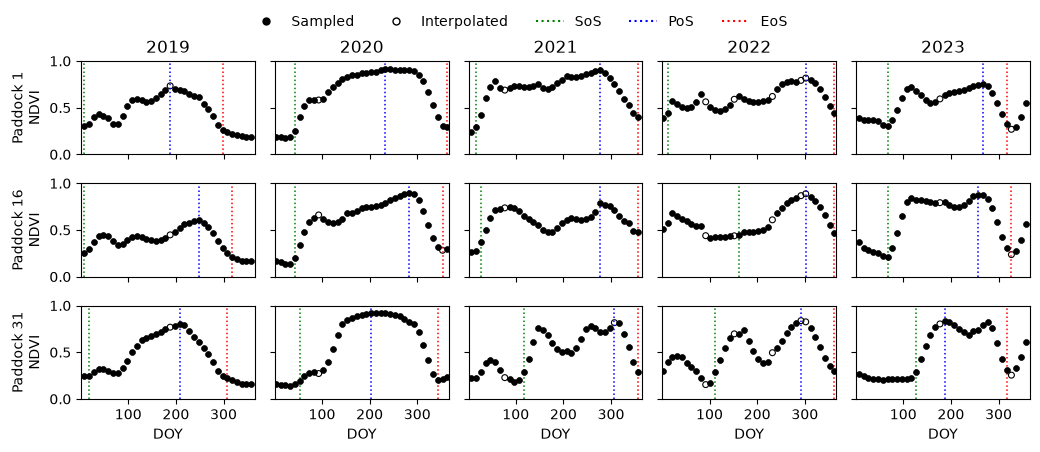

In [36]:
which_years = [2019, 2020, 2021, 2022, 2023]
which_paddocks = [1, 3, 15,16, 18,29, 31]

# ## v1
# which_years = [2019, 2022, 2023]
# which_paddocks = [3,  14, 31]

# ## v2
which_years = [2019, 2020, 2021, 2022, 2023]
which_paddocks = [1, 16, 31]


fig, axes = plot_phenology_grid(
    paddockts_years_auto,
    phenology_results,
    which_years=which_years,
    which_paddocks=which_paddocks,
)

plt.show()

In [37]:
# ## version 1 save:
# fig.savefig(
#     outpath / "phenology_example_v1.pdf",
#     bbox_inches="tight",
#     pad_inches=0.01,
# )

## version 2 save:
fig.savefig(
    outpath / "phenology_example_v2.pdf",
    bbox_inches="tight",
    pad_inches=0.01,
)

## Extrass

findfont: Failed to find font weight semibold, now using 700.


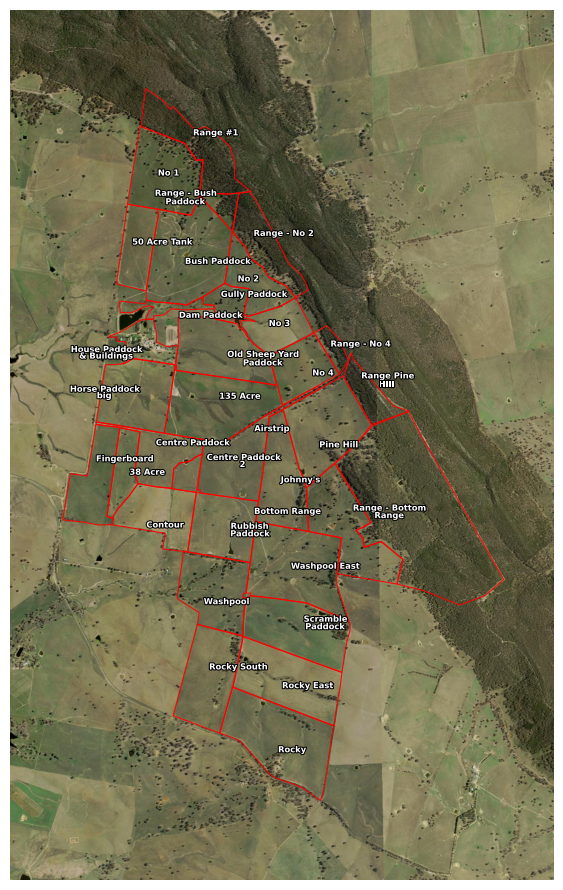

In [38]:
import textwrap

import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import numpy as np
import rasterio

from adjustText import adjust_text # may require pip install
from pathlib import Path
from rasterio.plot import plotting_extent


# ---------------------------------------------------------------------
# Settings
# ---------------------------------------------------------------------

aerial_path = Path("artifacts/Milgadara_NSW_imagery_z15.tif")

show_labels = True
label_fontsize = 6
label_wrap_width = 14


# ---------------------------------------------------------------------
# Prepare paddocks
# ---------------------------------------------------------------------

# Retain only paddock polygons if the original file contains landmarks etc.
if "type" in user_paddocks.columns:
    paddocks_plot = user_paddocks[
        (user_paddocks["type"] == "paddock")
        & user_paddocks.geometry.geom_type.isin(["Polygon", "MultiPolygon"])
    ].copy()
else:
    paddocks_plot = user_paddocks.copy()


# ---------------------------------------------------------------------
# Load aerial imagery
# ---------------------------------------------------------------------

with rasterio.open(aerial_path) as src:
    aerial = src.read([1, 2, 3])
    aerial_extent = plotting_extent(src)
    aerial_crs = src.crs

aerial_rgb = np.moveaxis(aerial, 0, -1)


# Reproject paddocks to match aerial imagery
paddocks_plot = paddocks_plot.to_crs(aerial_crs)


# ---------------------------------------------------------------------
# Plot
# ---------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(6, 9))

# Aerial image
ax.imshow(
    aerial_rgb,
    extent=aerial_extent,
    origin="upper",
)

# User-provided paddock boundaries
paddocks_plot.boundary.plot(
    ax=ax,
    color="red",
    linewidth=0.8,
    alpha=0.9,
    zorder=3,
)


# ---------------------------------------------------------------------
# Paddock labels
# ---------------------------------------------------------------------

if show_labels:

    texts = []

    for _, row in paddocks_plot.iterrows():

        # Guaranteed to fall within the polygon
        point = row.geometry.representative_point()

        # Wrap long paddock names
        label = "\n".join(
            textwrap.wrap(
                str(row["title"]),
                width=label_wrap_width,
            )
        )

        text = ax.text(
            point.x,
            point.y,
            label,
            fontsize=label_fontsize,
            fontweight="semibold",
            color="white",
            ha="center",
            va="center",
            linespacing=0.9,
            zorder=5,
            path_effects=[
                pe.withStroke(
                    linewidth=1.5,
                    foreground="black",
                )
            ],
        )

        texts.append(text)

    # Move labels to reduce overlap
    adjust_text(
        texts,
        ax=ax,
        only_move={"text": "xy"},
    )


# ---------------------------------------------------------------------
# Final formatting
# ---------------------------------------------------------------------

# Keep exactly the aerial-image extent
ax.set_xlim(aerial_extent[0], aerial_extent[1])
ax.set_ylim(aerial_extent[2], aerial_extent[3])

ax.set_axis_off()

plt.tight_layout()
plt.show()

[17 24 29 41 18 60 31  9 62 44]


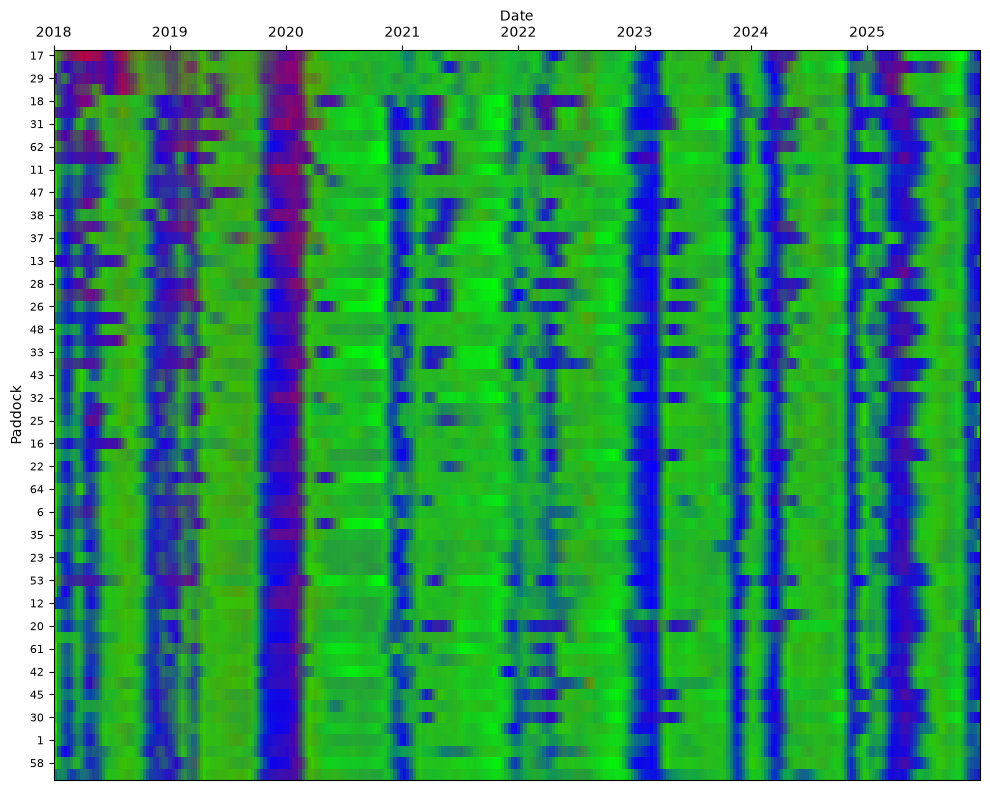

In [39]:
# Order paddocks by descending total bare ground across the full time series
# should name every paddock...
paddocks_by_bg = (
    paddockts_smoothed_auto["bg"]
    .sum(dim="time")
    .sortby(
        paddockts_smoothed_auto["bg"].sum(dim="time"),
        ascending=False
    )
    .paddock
    .values
)

print(paddocks_by_bg[:10])

fig, ax = plot_fractional_cover_heatmap(
    paddockts_smoothed_auto,
    paddocks=paddocks_by_bg,
    figsize=(10, 8),
    show_paddock_labels=True,
)

plt.show()

75th percentile BG threshold: 0.176


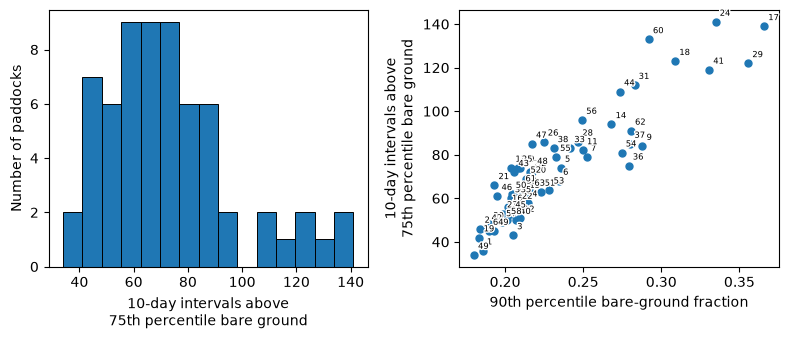

In [40]:
## Plot paddock-level drought exposure as frequency of bare ground versus severity of barest moment. 

# Global 75th-percentile bare-ground threshold
bg_threshold = float(
    paddockts_smoothed_auto["bg"]
    .quantile(0.75)
    .compute()
)

print(f"75th percentile BG threshold: {bg_threshold:.3f}")

# Number of 10-day intervals above the global threshold, per paddock
bg_exceedance_count = (
    (paddockts_smoothed_auto["bg"] > bg_threshold)
    .sum(dim="time")
    .compute()
)

# 90th percentile of bare-ground fraction, per paddock
bg_p90 = (
    paddockts_smoothed_auto["bg"]
    .quantile(0.90, dim="time")
    .compute()
)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, axes = plt.subplots(
    ncols=2,
    figsize=(8, 3.5),
)

# A. Distribution of exceedance frequency
ax = axes[0]

ax.hist(
    bg_exceedance_count.values,
    bins=15,
    edgecolor="black",
    linewidth=0.7,
)

ax.set_xlabel(
    "10-day intervals above\n75th percentile bare ground"
)
ax.set_ylabel("Number of paddocks")


# B. Frequency versus severity
ax = axes[1]

ax.scatter(
    bg_p90.values,
    bg_exceedance_count.values,
    s=25,
)

# Label points with paddock ID
for paddock, x, y in zip(
    bg_p90["paddock"].values,
    bg_p90.values,
    bg_exceedance_count.values,
):
    ax.annotate(
        str(int(paddock)),
        (x, y),
        xytext=(3, 3),
        textcoords="offset points",
        fontsize=6,
        ha="left",
        va="bottom",
        path_effects=[
            pe.withStroke(linewidth=2, foreground="white")
        ],
    )

ax.set_xlabel("90th percentile bare-ground fraction")
ax.set_ylabel(
    "10-day intervals above\n75th percentile bare ground"
)

plt.tight_layout()
plt.show()

fig.savefig(
    outpath / "drough_exposure_paddock_explorer.svg",
    bbox_inches="tight",
    pad_inches=0.02,
)

# this might be a nice axis against which to evaluate management and productivity.